In [4]:
import nltk
nltk.download('stopwords')

import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, classification_report
from nltk.corpus import stopwords
import re

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


In [5]:
# Load dataset
df = pd.read_csv("https://raw.githubusercontent.com/codebasics/nlp-tutorials/refs/heads/main/9_bag_of_words/spam.csv")

# Keep only useful columns
df = df[['Category', 'Message']]

# Rename for simplicity
df.columns = ['label', 'message']

# See what it looks like
df.head()

,label,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


label
ham     4825
spam     747
Name: count, dtype: int64


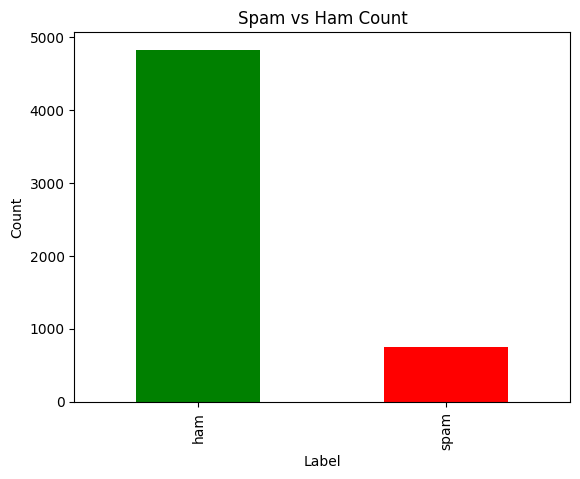

In [6]:
# How many spam vs ham?
print(df['label'].value_counts())

df['label'].value_counts().plot(kind='bar', color=['green', 'red'])
plt.title('Spam vs Ham Count')
plt.xlabel('Label')
plt.ylabel('Count')
plt.show()

In [7]:
stop_words = set(stopwords.words('english'))

def clean_text(text):
    # Lowercase everything
    text = text.lower()
    # Remove punctuation and numbers
    text = re.sub(r'[^a-z\s]', '', text)
    # Remove stopwords like "the", "is", "a"
    text = ' '.join([word for word in text.split()
                     if word not in stop_words])
    return text

# Apply cleaning to every message
df['clean_message'] = df['message'].apply(clean_text)

# Compare before and after
print("BEFORE:", df['message'][0])
print("AFTER:", df['clean_message'][0])

BEFORE: Go until jurong point, crazy.. Available only in bugis n great world la e buffet... Cine there got amore wat...
AFTER: go jurong point crazy available bugis n great world la e buffet cine got amore wat


In [8]:

cv = CountVectorizer()

X = cv.fit_transform(df['clean_message'])
y = df['label']

print("Shape of data:", X.shape)

Shape of data: (5572, 8480)


In [9]:
# Split into training and testing
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Train the model
model = MultinomialNB()
model.fit(X_train, y_train)

print("Model trained successfully!")

Model trained successfully!


In [10]:
# Make predictions
y_pred = model.predict(X_test)

# Check accuracy
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nDetailed Report:")
print(classification_report(y_test, y_pred))

Accuracy: 0.9713004484304932

Detailed Report:
              precision    recall  f1-score   support

         ham       0.99      0.97      0.98       966
        spam       0.85      0.96      0.90       149

    accuracy                           0.97      1115
   macro avg       0.92      0.97      0.94      1115
weighted avg       0.97      0.97      0.97      1115



In [12]:
# Function to predict if a message is spam or not
def predict_spam(message):
    # Clean the message using same cleaning function from Cell 4
    clean = clean_text(message)
    # Convert to numbers using same CountVectorizer from Cell 5
    vectorized = cv.transform([clean])
    # Predict using trained model from Cell 6
    prediction = model.predict(vectorized)
    # Return result
    return " SPAM" if prediction[0] == 'spam' else "NOT SPAM"


# Classic spam messages
print(predict_spam("Congratulations! You won a FREE iPhone. Click now!"))
print(predict_spam("WINNER! Claim your prize of $1000 now!"))
print(predict_spam("Free entry in our weekly competition. Text WIN to 87121"))

# Normal ham messages
print(predict_spam("Hey, are you coming to class tomorrow?"))
print(predict_spam("Can you send me the notes from today's lecture?"))
print(predict_spam("I'll meet you at the library at 5pm"))

print(predict_spam("You have been selected for a special offer"))
print(predict_spam("Please call me when you get this message"))

 SPAM
 SPAM
 SPAM
NOT SPAM
 SPAM
NOT SPAM
 SPAM
NOT SPAM
